# Customer Segmentation with K-Means

In the second phase of our project, we will implement `K-Means`, a foundational unsupervised machine learning algorithm designed for robust cluster analysis. By grouping data points based on inherent similarities, K-Means provides the granular insights necessary for sophisticated applications like marketing optimization and as intended for this project, customer segmentation.

When executed with precision, this algorithm transforms raw data into actionable intelligence, paving the way for more informed and successful business strategies.

The essential modules and libraries required for this implementation are detailed below:

In [ ]:
import sys
sys.path.append('../src')
from custom_functions import error_handling

In [5]:
try:
    import pandas as pd
    import numpy as np
    from sklearn.cluster import KMeans
    import seaborn as sns
    import matplotlib.pyplot as plt
    import plotly.express as px
    from sklearn.model_selection import RandomizedSearchCV
    import warnings
    warnings.filterwarnings("ignore")
    print('Libraries imported')
except Exception as e:
    error_handling(e)

Libraries imported


In the first of the project, after all the data was treated and cleaned, from the final dataframe we created the a file called `treated_data.csv` that is going to be used to build our dataframe and perform the customer segmentation

In [ ]:
file='../data/treated_data.csv'
df = pd.read_csv(file)
print(f"Number of clients: {df.shape[0]}\nNumber of features: {df.shape[1]}")

Let's display the columns and the head of the DataFrame 

In [9]:
pd.set_option('display.max_columns', 29)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Total_Spent,Highest_Spent,Age,Total_Purchases
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,...,10,4,7,0,0,0,0,0,0,1,1617,Wines,69,25
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,...,1,2,5,0,0,0,0,0,0,0,27,Wines,72,6
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,...,2,10,4,0,0,0,0,0,0,0,776,Wines,61,21
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,...,0,4,6,0,0,0,0,0,0,0,53,Meat,42,8
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,...,3,6,5,0,0,0,0,0,0,0,422,Wines,45,19


# RFM
**RFM (Recency, Frequency, Monetary)** is a technique widely used in customer relationship management and marketing to segment customers based on their purchasing behavior. It evaluates customers across three dimensions:

- **Recency:** How recently the customer made a purchase.
- **Frequency:** How often the customer makes purchases.
- **Monetary:** How much the customer has spent in total.

The features used to build our RFM model are derived directly from the dataset:

- **`Total_Purchases`** represents the sum of all purchases made across every available channel, making it our **Frequency** metric.
- **`Total_Spent`** represents the total amount of money spent by each client, serving as our **Monetary** metric.
- **`Recency`** captures the number of days since the client's last purchase, serving as our **Recency** metric.

For each RFM component, we use **`RandomizedSearchCV`** to find the optimal KMeans hyperparameters — namely `n_clusters`, `n_init`, `max_iter`, and the initialization method. Rather than exhaustively testing every combination, `RandomizedSearchCV` samples randomly from the parameter grid, making the search more efficient.

Once the best hyperparameters are identified for each component independently, three separate KMeans models are fitted — one per feature (`Total_Purchases`, `Total_Spent`, and `Recency`) — and the resulting cluster labels are stored in `Cluster_Frequency`, `Cluster_Purchases`, and `Cluster_Recency` respectively.

### Note:
There are a few ways to determine an optimal number of clusters, but we need to keep in mind the goal of our project: **make better decisions based on customer behavior**. 

For that reason, we define the search space between 2 and 4 clusters (`'n_clusters': [i for i in range(2,5)]`) and let the algorithm determine the optimal number. Having 10 or 20 clusters wouldn't be viable — we need a limited number of groups in order to translate them into concrete, scalable business actions.

In [14]:
SEED = 1234
np.random.seed(SEED)
kmeans = KMeans(random_state=SEED)
parameters = {'n_clusters': [i for i in range(2,5)], 'init':['k-means++', 'random'], 
              'n_init':[10,20,30,40,50], 'max_iter':[300,500,700,100]}
random_search = RandomizedSearchCV(kmeans, parameters, random_state=SEED)

# `Cluster_Frequency`

In [16]:
random_search.fit(df[['Total_Purchases']])
frequency_best_params = random_search.best_params_
frequency_best_score = random_search.best_score_
print('Best parameters for Frequency: ', *[f'{k} : {v} |' for k,v in frequency_best_params.items()])
print("Best score for Frequency: ", frequency_best_score)

Best parameters for Frequency:  n_init : 30 | n_clusters : 4 | max_iter : 500 | init : random |
Best score for Frequency:  -1989.5993461036724


In [17]:
kmeans_freq = KMeans(**frequency_best_params)
df['Cluster_Frequency'] = kmeans_freq.fit_predict(df[['Total_Purchases']])
print('Frequency successfully grouped')

Frequency successfully grouped


In [18]:
display(df['Cluster_Frequency'].head().to_frame())

,Cluster_Frequency
0,2
1,0
2,3
3,0
4,3


# `Cluster_Monetary`

In [20]:
random_search.fit(df[['Total_Spent']])
monetary_best_params = random_search.best_params_
monetary_best_score = random_search.best_score_
print('Best parameters for Frequency: ', *[f'{k} : {v} |' for k,v in monetary_best_params.items()])
print("Best score for Frequency: ", monetary_best_score)

Best parameters for Frequency:  n_init : 30 | n_clusters : 4 | max_iter : 500 | init : k-means++ |
Best score for Frequency:  -9342643.11884369


In [21]:
kmeans_monetary = KMeans(**monetary_best_params)
df['Cluster_Monetary'] = kmeans_monetary.fit_predict(df[['Total_Spent']])
print('Monetary successfully grouped')

Monetary successfully grouped


In [22]:
display(df['Cluster_Monetary'].head().to_frame())

,Cluster_Monetary
0,1
1,0
2,2
3,0
4,2


# `Cluster_Recency`

In [24]:
random_search.fit(df[['Recency']]) 
recency_best_params = random_search.best_params_
recency_best_score = random_search.best_score_
print('Best parameters for Frequency: ', *[f'{k} : {v} |' for k,v in recency_best_params.items()])
print("Best score for Frequency: ", recency_best_score)

Best parameters for Frequency:  n_init : 50 | n_clusters : 4 | max_iter : 700 | init : random |
Best score for Frequency:  -23762.11605628204


In [25]:
kmeans_recency = KMeans(**recency_best_params)
df['Cluster_Recency'] = kmeans_recency.fit_predict(df[['Recency']])
print('Recency successfully grouped')

Recency successfully grouped


In [26]:
display(df['Cluster_Recency'].head().to_frame())

,Cluster_Recency
0,3
1,1
2,1
3,1
4,0


In [27]:
df[['ID','Cluster_Recency', 'Cluster_Monetary', 'Cluster_Frequency']].head()

,ID,Cluster_Recency,Cluster_Monetary,Cluster_Frequency
0,5524,3,1,2
1,2174,1,0,0
2,4141,1,2,3
3,6182,1,0,0
4,5324,0,2,3


# Creating a Score

Now that each customer has been assigned to a cluster for every RFM component, we can start building a score. To do this, we group the clusters by their average value per component and assign a score ranging from 0 to 3.

The scoring logic reflects the nature of each component:

- **Frequency & Monetary** — the higher the cluster average, the higher the score. Customers who buy more often and spend more should rank higher.
- **Recency** — the lower the cluster average, the higher the score. A smaller recency value means the customer purchased more recently, which is a positive signal.

This gives us a simple, interpretable score per component that can later be combined into a single RFM score for each customer.

In [29]:
frequency_group = df.groupby('Cluster_Frequency')['Total_Purchases'].mean().sort_values(ascending=True).to_frame().reset_index()
frequency_group['index'] = frequency_group.index
frequency_group

,Cluster_Frequency,Total_Purchases,index
0,0,6.612048,0
1,1,14.460076,1
2,3,20.839934,2
3,2,27.443636,3


In [30]:
recency_group = df.groupby('Cluster_Recency')['Recency'].mean().sort_values(ascending=False).to_frame().reset_index()
recency_group['index'] = recency_group.index
recency_group

,Cluster_Recency,Recency,index
0,0,85.256822,0
1,3,57.913621,1
2,1,32.801556,2
3,2,10.082329,3


In [31]:
purchases_group = df.groupby('Cluster_Monetary')['Total_Spent'].mean().sort_values(ascending=True).to_frame().reset_index()
purchases_group['index'] = purchases_group.index
purchases_group

,Cluster_Monetary,Total_Spent,index
0,0,100.580374,0
1,2,573.418605,1
2,3,1112.555310,2
3,1,1753.589474,3


In [32]:
frequency_score = {2:0,0:1,1:2,3:3}
recency_score = {0:0, 2:1, 1:2, 3:3}
monetary_score = {2:0,1:1,3:2,0:3}
df['Frequency_Score'] = df['Cluster_Frequency'].map(frequency_score)
df['Recency_Score'] = df['Cluster_Recency'].map(recency_score)
df['Monetary_Score'] = df['Cluster_Monetary'].map(monetary_score)
df[['Frequency_Score','Recency_Score', 'Monetary_Score']].head()

,Frequency_Score,Recency_Score,Monetary_Score
0,0,3,1
1,1,2,3
2,3,2,0
3,1,2,3
4,3,0,0


With a score assigned to each component, we can now combine them into a single `RFM_Score` ranging from 0 to 9. This will be the parameter that classifies each customer as `Premium`, `Loyal`, `Moderate`, `Occasional`, or `Inactive`.

In [34]:
df['RMF_Score'] = df[['Frequency_Score','Recency_Score', 'Monetary_Score']].sum(axis = 1)
df[['ID','RMF_Score']] 

,ID,RMF_Score
0,5524,4
1,2174,6
2,4141,5
3,6182,6
4,5324,3
...,...,...
2232,10870,8
2233,4001,6
2234,7270,5
2235,8235,4


__Let assign to each costumer a segmenation, based on their scores__

- __RMF Score = `0` -> Inactive__
- __RMF Score = `1` or `2` -> Occasional__
- __RMF Score = `3` or `4` -> Moderate__
- __RMF Score = `5` or `5` -> Loyal__
- __RMF Score = `7`, `8`, or `9` -> Premium__


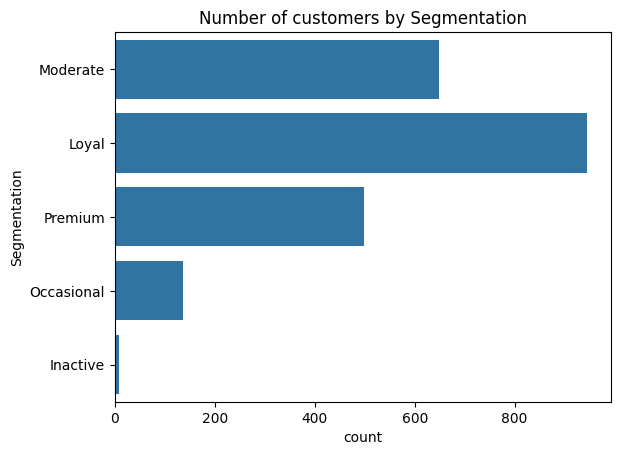

In [36]:
df['Segmentation'] = 'Inactive'
df.loc[df['RMF_Score']>=1, 'Segmentation'] = 'Occasional'
df.loc[df['RMF_Score']>=3, 'Segmentation'] = 'Moderate'
df.loc[df['RMF_Score']>=5, 'Segmentation'] = 'Loyal'
df.loc[df['RMF_Score']>=7, 'Segmentation'] = 'Premium'
sns.countplot(df['Segmentation'])
plt.title('Number of customers by Segmentation')
plt.show()

__Let's now plot a 3d Scatterplot showing the clusters and its components and the three components of our score__

In [38]:
import dash
from dash import dcc, html, Input, Output


# Assuming 'df' is your existing DataFrame
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Customer Segmentation Explorer", style={'textAlign': 'center'}),
    
    html.Div([
        html.Label("Select Segmentation:"),
        dcc.Dropdown(
            id='segment-dropdown',
            # Adds an 'All' option plus all unique segments in your data
            options=[{'label': 'All Segments', 'value': 'All'}] + 
                    [{'label': i, 'value': i} for i in df['Segmentation'].unique()],
            value='All',
            clearable=False
        ),
    ], style={'width': '30%', 'margin': '0 auto', 'padding': '20px'}),

    dcc.Graph(id='rfm-3d-scatter', style={'height': '80vh'})
])

@app.callback(
    Output('rfm-3d-scatter', 'figure'),
    Input('segment-dropdown', 'value')
)
def update_graph(selected_segment):
    # Filter data based on dropdown selection
    if selected_segment == 'All':
        filtered_df = df
    else:
        filtered_df = df[df['Segmentation'] == selected_segment]
    
    fig = px.scatter_3d(
        filtered_df, 
        x='Total_Purchases', 
        y='Recency', 
        z='Total_Spent', 
        color='Segmentation',
        labels={
            'Total_Purchases': 'Frequency',
            'Recency': 'Recency (days)',
            'Total_Spent': 'Monetary'
        },
        title=f'Customer Segmentation: {selected_segment}'
    )
    
    # Improve layout for better 3D visibility
    fig.update_layout(margin=dict(l=0, r=0, b=0, t=50))
    
    return fig

if __name__ == '__main__':
    app.run_server(debug=True)

# Average Purchase Value (APV)

__Average Purchase Value (APV) is the average amount spent by a customer on a single transaction (`df['Total_Purchases']/df['Frequency']`). Let's create the column corresponding to this feature and the, group the customer by segmentation and see the Average Purchase Value for each category__

In [40]:
df['APV'] = np.where(df['Total_Purchases'] > 0, df['Total_Spent'] / df['Total_Purchases'], 0)

In [41]:
df.groupby('Segmentation')['APV'].mean()

Segmentation
Inactive      26.441074
Loyal         31.902801
Moderate      35.437839
Occasional    42.131824
Premium       30.883057
Name: APV, dtype: float64

---

## What's Next

This notebook covers the full pipeline — from raw data to customer segmentation and RFM scoring. The trained dataset will now serve as the foundation for three next steps:

**1. Streamlit Dashboard**
The segmented data will be used to build an interactive dashboard aimed at a business audience. The goal is to translate the technical output of this analysis into clear, actionable visualizations — allowing stakeholders to explore customer segments, monitor KPIs, and support decision-making without needing to interact with the underlying code.

**2. XGBoost Regression Model**
A gradient boosting model will be trained to predict `Total_Spent` for new customers who don't yet have a full purchase history. This predicted value feeds directly into the RFM scoring pipeline, filling in the monetary component before segmentation takes place.

**3. Synthetic Data, BigQuery & Classification Model**
Synthetic data will be generated based on the statistical properties of the original dataset and uploaded to BigQuery. From there, a classification model will be trained to assign new customers to a segment — consuming the RFM score built on top of the XGBoost predictions, completing the end-to-end pipeline:

`Raw customer data → XGBoost (predict Total_Spent) → RFM Score → Classifier (assign Segment)`